In [ ]:
# Day 2: OpenCV Fundamentals
# Covers: Load image,
# crop with NumPy indexing,
# blur with GaussianBlur,
# edge detection with Canny.

In [ ]:
!pip install -q ultralytics

In [ ]:
from ultralytics import YOLO

model = YOLO('yolov8n.pt')
results = model.predict(source='/content/football image.jpg', conf=0.5)

for r in results:
    print(f"Image size: {r.orig_shape}")
    print(f"Total detections: {len(r.boxes)}")
    for box in r.boxes:
        class_id = int(box.cls[0])
        conf = box.conf[0]
        print(f"  Class ID: {class_id}, Confidence: {conf:.2f}")


image 1/1 /content/football image.jpg: 448x640 3 persons, 1 sports ball, 324.5ms
Speed: 13.6ms preprocess, 324.5ms inference, 37.9ms postprocess per image at shape (1, 3, 448, 640)
Image size: (408, 612)
Total detections: 4
  Class ID: 32, Confidence: 0.92
  Class ID: 0, Confidence: 0.92
  Class ID: 0, Confidence: 0.91
  Class ID: 0, Confidence: 0.84


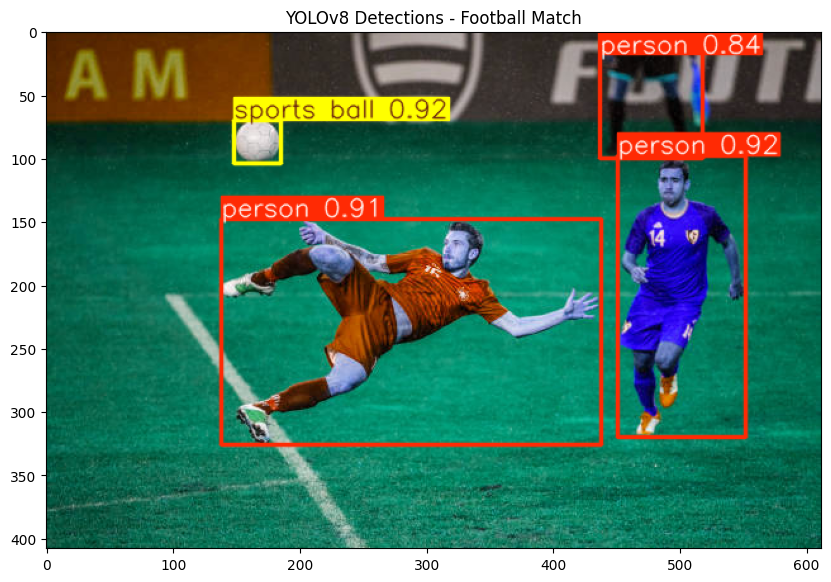

In [ ]:
annotated = results[0].plot()

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 10))
plt.imshow(annotated)
plt.axis('on')
plt.title('YOLOv8 Detections - Football Match')
plt.show()

In [ ]:
for box in r.boxes:
    print(box.xyxy)  # This contains the coordinates

tensor([[148.3300,  70.2681, 185.0242, 104.3261]])
tensor([[451.2127,  98.5870, 552.1287, 320.8136]])
tensor([[138.4861, 148.4354, 438.6687, 326.8339]])
tensor([[437.5930,   0.9796, 518.3862, 100.0616]])


In [ ]:
# Step 1: Load the image
# You need to use a library that can read images and convert to NumPy array.
# Hint: Use Image from PIL and numpy.
# Write the code to load /content/football image.jpg into a variable called img.


from PIL import Image
import numpy as np

img = np.array(Image.open("/content/football image.jpg"))
print(img.shape)

(408, 612, 3)


In [ ]:
# Step 2: Get the ball's bounding box from YOLO
# Before you can crop, you need YOLO to tell you where the ball is.
# Hint: Use YOLO model to predict on the image, then extract the first detection's coordinates.
# Write code to:

# Load the YOLOv8 model
# Run inference on img
# Get the bounding box of the ball (not a person)
# Extract x1, y1, x2, y2 coordinates

# (Remember: Class ID 32 is sports ball)

from ultralytics import YOLO

model = YOLO('yolov8n.pt')

results = model.predict(source='/content/football image.jpg', conf=0.5)
for box in results[0].boxes:
    if int(box.cls[0]) == 32:  # Check if it's a ball
        co_or = box.xyxy[0]
        x1,y1,x2,y2 = int(co_or[0]),int(co_or[1]),int(co_or[2]),int(co_or[3])
        print(x1,y1,x2,y2)

        # Print them

# first_box = result[0].box[0]
# co_or = first_box.xyxy[0]
# x1,y1,x2,y2 = int(co_or[0]),int(co_or[1]),int(co_or[2]),int(co_or[3])
# print(x1,y1,x2,y2)


image 1/1 /content/football image.jpg: 448x640 3 persons, 1 sports ball, 255.4ms
Speed: 7.4ms preprocess, 255.4ms inference, 2.7ms postprocess per image at shape (1, 3, 448, 640)
148 70 185 104


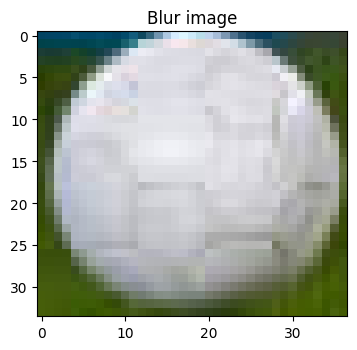

In [ ]:
# Step 3: Crop the ball region
# Now crop img using these coordinates.
# Remember: Images are indexed as [rows, columns] which is [y, x].
# Hint: Use NumPy array slicing.
# Write code to extract just the ball region into a variable called ball_crop.

from PIL import Image as PILImage
import matplotlib.pyplot as plt

ball_crop = img[y1:y2,x1:x2]
plt.figure(figsize=(4,4))
plt.imshow(ball_crop)
plt.title("Blur image")
plt.show()

In [ ]:
# Step 4: Blur the cropped ball
# Hint: Use GaussianBlur from OpenCV.
# Write code to blur ball_crop with a kernel size of (3, 3) and sigma of 1.
#Store result in blurred_ball.
import cv2
blur_ball = cv2.GaussianBlur(ball_crop,(3,3),1)
print("Blurred shape:", blur_ball.shape)

Blurred shape: (34, 37, 3)


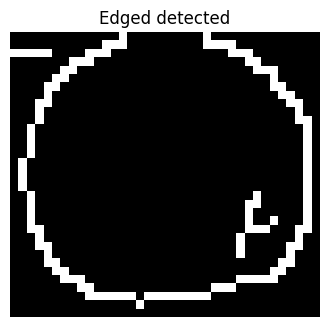

In [ ]:
# Step 5: Edge Detection
# Hint: Use Canny from OpenCV.
# Write code to detect edges on blur_ball with thresholds of 50 and 150.
#Store result in edges.

import matplotlib.pyplot as plt
edges = cv2.Canny(blur_ball,50,150)

plt.figure(figsize= (4,4))
plt.imshow(edges,cmap='gray')
plt.title("Edged detected")
plt.axis("off")
plt.show()